In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import scienceplots
plt.style.use(['science', 'no-latex'])

from utils import quality_metrics
# Import the display functions
from utils.display_metrics_table import (
    display_metrics_table, 
    print_metrics_summary
)

# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)

IMAGES_PATH = "/Users/klemenkubelj/Documents/school/graduate/masters/code/cvar-masters-thesis-2025/figures"

In [4]:
plt.rcParams.update({
    'font.size': 14,          # General font size
    'axes.titlesize': 16,     # Title font size
    'axes.labelsize': 14,     # X and Y label font size
    'xtick.labelsize': 14,    # X-axis tick label size
    'ytick.labelsize': 14,    # Y-axis tick label size
    'legend.fontsize': 12,    # Legend font size
    'figure.titlesize': 18,    # Figure title (suptitle) font size

    "axes.axisbelow": True
})

In [5]:
!which python

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [6]:
events = [
    2010,
    2012,
    2014,
    2023,
]

In [7]:
df = pd.read_excel(os.path.join("../data/predicted_flood_depths_with_water_distance_2025-05-13.xlsx"))
df = df[
    df["measured_depth"]<4
]
df.shape
# Replace 0 values with 0.01 for all measured_depth
# df["measured_depth"] = df["measured_depth"].replace(0, 0.01)

# Set DogeodekLabel columns
_map = {
    14: 2010,
    18: 2012,
    24: 2014,
    68: 2023,
}
df["DogodekLabel"] = df["DogodekId"].map(_map)

In [8]:
df.head()

,VlogaId,Objekt_Naslov,Objekt_Naslov_PostnaStevilka,Objekt_Parcela_Stevilka,Objekt_Parcela_KoId,Objekt_UporabnaPovrsina,Objekt_VisinaVodeCm,Objekt_StopnjaPoskodovanosti,Skoda_DatumOcene,Objekt_VrstaObjektaId,DogodekId,Vrednost,OdstPoskodovanostiObjekta,SkupnaSkoda,SkupnaSkodaSource,geometry,gps_lat,gps_lng,predicted_wri_depth,predicted_si_depth,predicted_si_old_depth,predicted_wri_damage,predicted_si_damage,predicted_si_old_damage,measured_depth,distance_to_water,DogodekLabel
0,147651,Cesta med vinogradi 48,6000 KOPER - CAPODISTRIA,5743/6,715,50.0,30.0,NaN,09/30/10 00:00:00,2.0,14,NaN,NaN,NaN,NaN,POINT (405228.12739536207 46848.09332348127),45.555094,13.786126,0.000000,1.5,0.0,0.000000,0.500,0.0,0.3,51.774728,2010
1,147686,Cesta med vinogradi 46,6000 KOPER - CAPODISTRIA,5743/10,715,55.0,50.0,NaN,09/30/10 00:00:00,2.0,14,NaN,NaN,NaN,NaN,POINT (405207.1266384774 46826.09359404445),45.554893,13.785861,0.000000,0.5,0.0,0.000000,0.250,0.0,0.5,77.397335,2010
2,147692,Cesta med vinogradi 46,6000 KOPER - CAPODISTRIA,5743/10,715,38.0,50.0,NaN,09/30/10 00:00:00,2.0,14,NaN,NaN,NaN,NaN,POINT (405207.1266384774 46826.09359404445),45.554893,13.785861,0.000000,0.5,0.0,0.000000,0.250,0.0,0.5,77.397335,2010
3,147704,Cesta med vinogradi 48,6000 KOPER - CAPODISTRIA,5743/6,715,80.0,40.0,NaN,09/30/10 00:00:00,2.0,14,NaN,NaN,NaN,NaN,POINT (405228.12739536207 46848.09332348127),45.555094,13.786126,0.000000,1.5,0.0,0.000000,0.500,0.0,0.4,51.774728,2010
4,147723,Železniška cesta 8,6280 ANKARAN - ANCARANO,877/7,705,290.0,130.0,NaN,10/01/10 00:00:00,8.0,14,NaN,NaN,NaN,NaN,POINT (402903.1218190783 47653.158125260845),45.562016,13.756194,0.482443,2.5,0.0,0.241221,0.675,0.0,1.3,455.622715,2010


In [9]:
df = df[[
    "VlogaId",
    "DogodekId",
    "DogodekLabel",
    "gps_lat",
    "gps_lng",
    "measured_depth",
    "predicted_wri_depth",
    "predicted_si_depth",
    "distance_to_water",
]]

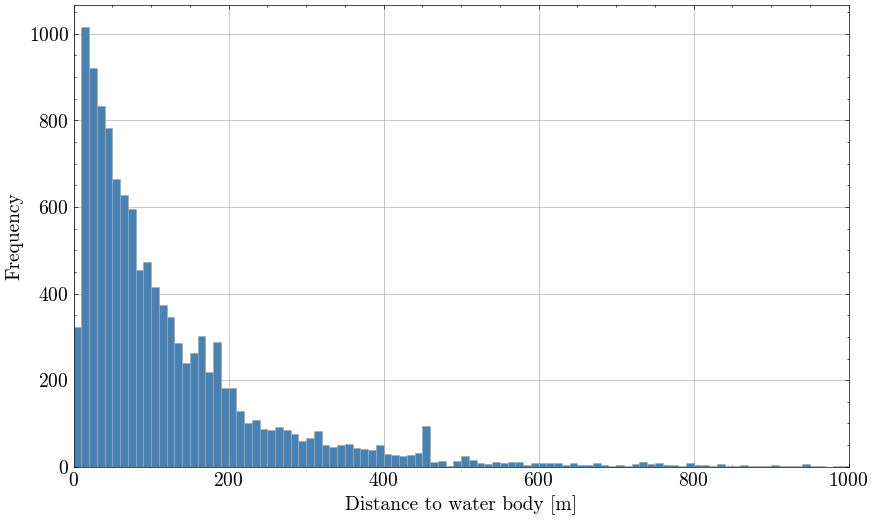

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(df["distance_to_water"], edgecolor="darkgrey", color="steelblue", linewidth=0.5, bins=np.linspace(0, 1000, 101))
plt.xlabel("Distance to water body [m]")
plt.ylabel("Frequency")
plt.grid(True)
plt.xlim(0,1000)

plt.savefig(IMAGES_PATH + "/05/water_proximity_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

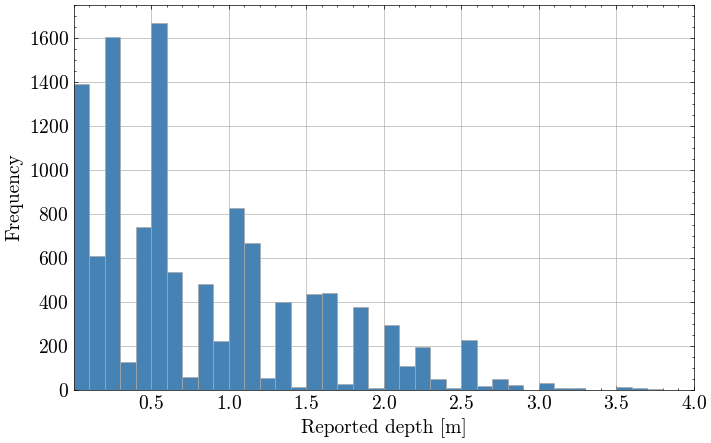

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["measured_depth"], edgecolor="darkgrey", color="steelblue", linewidth=0.5, bins=np.linspace(0, 4, 41))
plt.xlabel("Reported depth [m]")
plt.ylabel("Frequency")
plt.grid(True)
plt.xlim(0, 4)

# Set x-axis ticks at regular intervals (every 0.5m) to align with data
plt.xticks(np.arange(0.5, 4.5, 0.5))

# plt.show()
plt.savefig(IMAGES_PATH + "/05/validation_depth_histogram.pdf", dpi=300, bbox_inches="tight")

In [12]:
# Show number of samples, split by event
event_sample_counts = df["DogodekLabel"].value_counts()
print("Number of samples split by event:")
print(event_sample_counts)

df.shape

Number of samples split by event:
DogodekLabel
2023    6568
2010    2477
2012    1797
2014     898
Name: count, dtype: int64


(11740, 9)

In [13]:
# Calculate the errors
# If df["predicted_si_depth"] is 0, set it to 0.5.
# df["predicted_si_depth"] = df["predicted_si_depth"].clip(lower=0.5)
df["si_error"] = df["measured_depth"] - df["predicted_si_depth"]
df["wri_error"] = df["measured_depth"] - df["predicted_wri_depth"]

In [14]:
df["predicted_si_depth"].value_counts()

predicted_si_depth
0.0    5063
0.5    3593
1.5    2634
2.5     450
Name: count, dtype: int64

### Segmentation by flood event

In [15]:
print(f"Total")
_df = df.copy()
_df = _df[_df["distance_to_water"]<100]
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth"]))
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth"]))
print("-"*100)

for event_label in events:
    print(f"Event: {event_label}")
    _df = df.copy()
    _df = _df[_df["DogodekLabel"]==event_label]
    _df = _df[_df["distance_to_water"]<100]
    print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth"]))
    print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth"]))
    print("-"*100)

Total
{'within_20': 0.1986, 'median_error': 0.2, 'mean_error': 0.1506, 'median_absolute_error': 0.5, 'RMSE': 0.935, 'st_dev_residuals': 5.6259, 'total_samples': 6691}
{'within_20': 0.1109, 'median_error': 0.5674, 'mean_error': 0.7226, 'median_absolute_error': 0.6, 'RMSE': 1.0336, 'st_dev_residuals': 1.6237, 'total_samples': 6691}
----------------------------------------------------------------------------------------------------
Event: 2010
{'within_20': 0.3309, 'median_error': -0.5, 'mean_error': -0.3941, 'median_absolute_error': 0.6, 'RMSE': 0.9849, 'st_dev_residuals': 3.8043, 'total_samples': 1369}
{'within_20': 0.2637, 'median_error': 0.4, 'mean_error': 0.5019, 'median_absolute_error': 0.4, 'RMSE': 0.7566, 'st_dev_residuals': 0.5403, 'total_samples': 1369}
----------------------------------------------------------------------------------------------------
Event: 2012
{'within_20': 0.3917, 'median_error': 0.0, 'mean_error': -0.1274, 'median_absolute_error': 0.5, 'RMSE': 0.9624, 'st_

In [16]:
def plot_errors_histogram(df, true_column, predicted_column, title: str = "Histogram of Errors", ax=None):
    if ax is None:
        ax = plt.gca()
        
    errors = df[true_column] - df[predicted_column]
    ax.hist(errors, bins=30, edgecolor="darkgrey", color="steelblue", linewidth=0.5)
    ax.set_title(f"{title}", fontsize=14)
    ax.set_xlabel("Error [m]", fontsize=14)
    ax.set_ylabel("Frequency", fontsize=14)
    ax.grid(alpha=1)
    
    median_error = errors.median()
    mean_error = errors.mean()
    mae_error = np.mean(abs(errors))
    rmse_error = np.sqrt(np.mean(errors**2))
    std_error = errors.std()
    ax.axvline(mean_error, color="red", linestyle="dashed", linewidth=1)
    # ax.axvline(0, color="darkgrey", linestyle="solid", linewidth=1)  # Draw a line at x=0
    
    # Set x-axis limits to ensure 0 is in the middle
    max_abs_error = max(abs(errors.min()), abs(errors.max()))
    ax.set_xlim(-max_abs_error, max_abs_error)
    
    # Get the current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Place text in top right corner
    # stats_text = f"Median: {median_error:.2f}\nMean: {mean_error:.2f}\nMAE: {mae_error:.2f}\nRMSE: {rmse_error:.2f}\nStd: {std_error:.2f}"
    # ax.text(
    #     xlim[1] * 0.95,  # x position (95% of the way to the right)
    #     ylim[1] * 0.95,  # y position (95% of the way to the top)
    #     stats_text,
    #     color="red",
    #     ha="right",  # horizontal alignment
    #     va="top",    # vertical alignment
    #     bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2)  # white background box
    # )
    print(f"{title} Mean: {mean_error:.4f}")

SI IKG Prediction Errors - Event 2010 Mean: -0.3295
SI IKG Prediction Errors - Event 2012 Mean: 0.0977
SI IKG Prediction Errors - Event 2014 Mean: 0.0828
SI IKG Prediction Errors - Event 2023 Mean: 0.4998


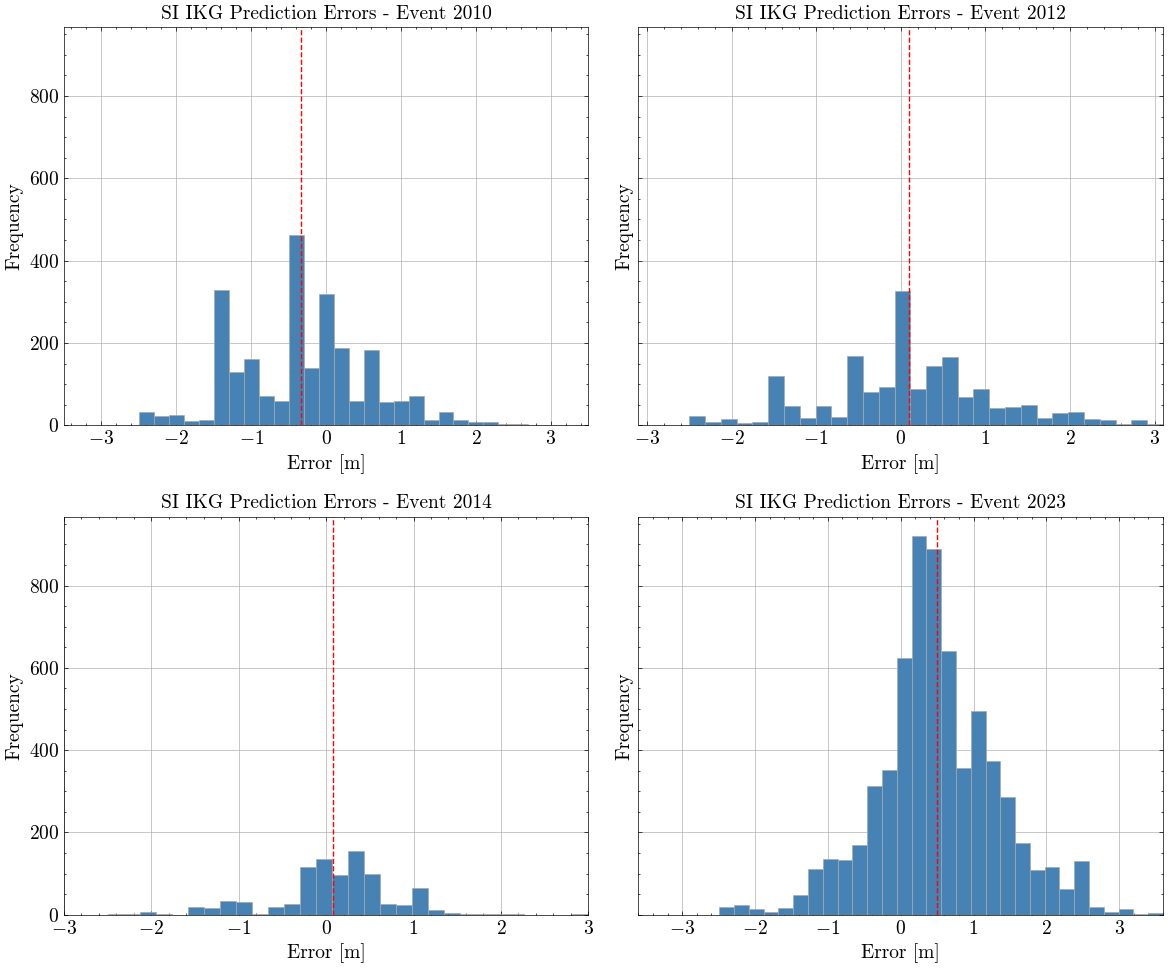

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_label in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekLabel"]==event_label]
    # _df = _df[_df["distance_to_water"]<50]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_si_depth",
        title=f"SI IKG Prediction Errors - Event {event_label}",
        ax=axes[row, col]
    )

plt.tight_layout()
plt.savefig(IMAGES_PATH + "/05/si_ikg_bias_histograms.pdf", dpi=300, bbox_inches="tight")
plt.show()

Measured Depth - Predicted SI Depth Mean: 0.2314


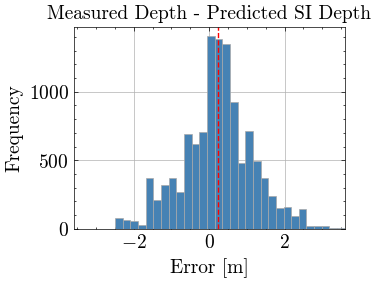

In [18]:
plot_errors_histogram(df, "measured_depth", "predicted_si_depth", title="Measured Depth - Predicted SI Depth")

WRI Prediction Errors - Event 2010 Mean: 0.4929
WRI Prediction Errors - Event 2012 Mean: 0.5567
WRI Prediction Errors - Event 2014 Mean: 0.3728
WRI Prediction Errors - Event 2023 Mean: 0.9046


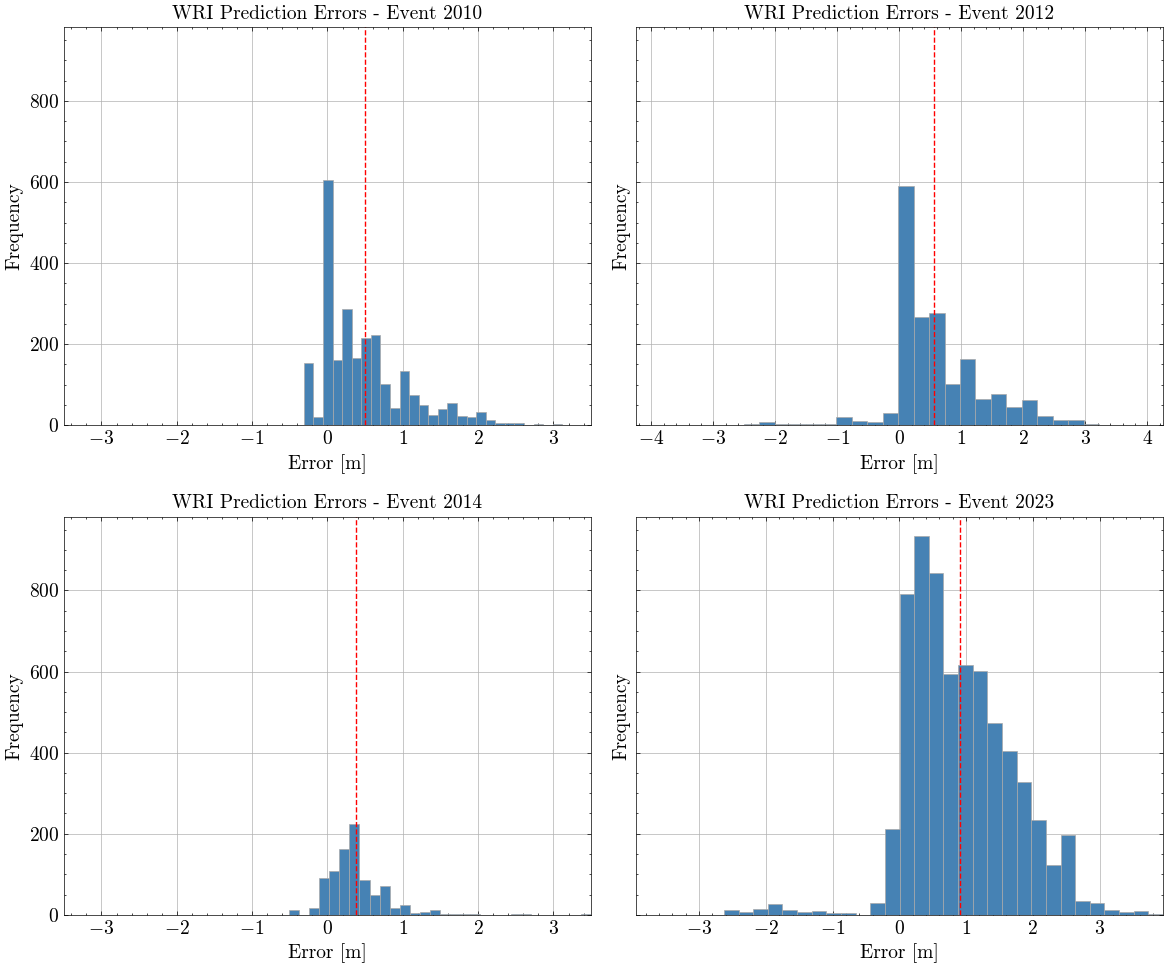

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_label in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekLabel"]==event_label]
    # _df = _df[_df["distance_to_water"]<50]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_wri_depth",
        title=f"WRI Prediction Errors - Event {event_label}",
        ax=axes[row, col]
    )

plt.tight_layout()
plt.savefig(IMAGES_PATH + "/05/wri_bias_histograms.pdf", dpi=300, bbox_inches="tight")
plt.show()

Measured Depth - Predicted WRI Depth Mean: 0.7238


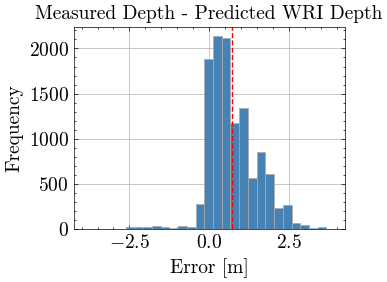

In [20]:
plot_errors_histogram(df, "measured_depth", "predicted_wri_depth", title="Measured Depth - Predicted WRI Depth")

# Bias-adjusted columns

In [21]:
df.head()

,VlogaId,DogodekId,DogodekLabel,gps_lat,gps_lng,measured_depth,predicted_wri_depth,predicted_si_depth,distance_to_water,si_error,wri_error
0,147651,14,2010,45.555094,13.786126,0.3,0.000000,1.5,51.774728,-1.2,0.300000
1,147686,14,2010,45.554893,13.785861,0.5,0.000000,0.5,77.397335,0.0,0.500000
2,147692,14,2010,45.554893,13.785861,0.5,0.000000,0.5,77.397335,0.0,0.500000
3,147704,14,2010,45.555094,13.786126,0.4,0.000000,1.5,51.774728,-1.1,0.400000
4,147723,14,2010,45.562016,13.756194,1.3,0.482443,2.5,455.622715,-1.2,0.817557


In [22]:
df["predicted_si_depth_bias_adjusted"] = df.groupby("DogodekId").apply(
    lambda x: (x["predicted_si_depth"] + (x["si_error"]).mean()).clip(lower=0)
).reset_index(level=0, drop=True)


df["predicted_wri_depth_bias_adjusted"] = df.groupby("DogodekId").apply(
    lambda x: (x["predicted_wri_depth"] + (x["wri_error"]).mean()).clip(lower=0)
).reset_index(level=0, drop=True)

In [23]:
df.tail(20)

,VlogaId,DogodekId,DogodekLabel,gps_lat,gps_lng,measured_depth,predicted_wri_depth,predicted_si_depth,distance_to_water,si_error,wri_error,predicted_si_depth_bias_adjusted,predicted_wri_depth_bias_adjusted
13508,1456697,68,2023,46.255995,15.099222,0.70,0.238227,0.0,74.629669,0.70,0.461773,0.499761,1.142834
13510,1456701,68,2023,46.186888,14.598643,1.90,0.000000,0.5,143.901461,1.40,1.900000,0.999761,0.904607
13512,1456703,68,2023,46.260228,15.092671,0.25,0.238227,0.0,244.549893,0.25,0.011773,0.499761,1.142834
13513,1456705,68,2023,46.136919,14.558394,0.60,0.000000,0.0,101.085842,0.60,0.600000,0.499761,0.904607
13514,1456708,68,2023,46.190071,14.547735,0.70,0.000000,0.5,23.593666,0.20,0.700000,0.999761,0.904607
13515,1456709,68,2023,46.187731,14.597833,0.70,0.000000,1.5,217.603060,-0.80,0.700000,1.999761,0.904607
13516,1456717,68,2023,46.241212,15.192853,0.05,0.238227,0.5,27.935236,-0.45,-0.188227,0.999761,1.142834
13517,1456721,68,2023,46.244532,15.190517,0.35,0.238227,0.0,392.351381,0.35,0.111773,0.499761,1.142834
13518,1456729,68,2023,46.484655,14.874586,0.40,0.000000,0.0,20.200869,0.40,0.400000,0.499761,0.904607
13519,1456732,68,2023,46.485850,14.871476,1.20,0.000000,0.0,20.972077,1.20,1.200000,0.499761,0.904607


SI IKG Prediction Errors - Bias Adjusted - Event 2010 Mean: -0.0770
SI IKG Prediction Errors - Bias Adjusted - Event 2012 Mean: 0.0000
SI IKG Prediction Errors - Bias Adjusted - Event 2014 Mean: -0.0000
SI IKG Prediction Errors - Bias Adjusted - Event 2023 Mean: -0.0000


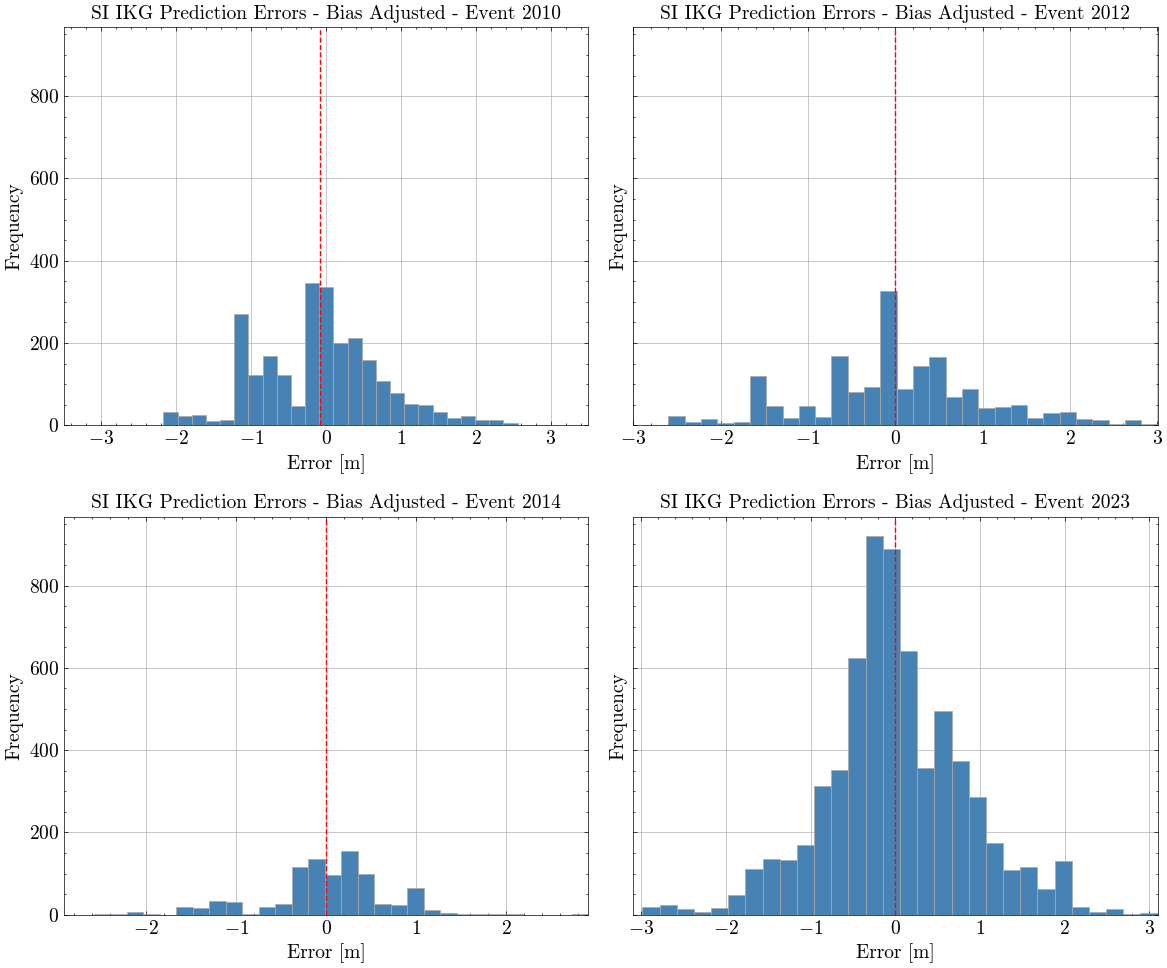

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_label in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekLabel"]==event_label]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_si_depth_bias_adjusted",
        title=f"SI IKG Prediction Errors - Bias Adjusted - Event {event_label}",
        ax=axes[row, col]
    )

plt.tight_layout()
plt.show()

WRI Prediction Errors - Bias Adjusted - Event 2010 Mean: 0.0000
WRI Prediction Errors - Bias Adjusted - Event 2012 Mean: 0.0000
WRI Prediction Errors - Bias Adjusted - Event 2014 Mean: 0.0000
WRI Prediction Errors - Bias Adjusted - Event 2023 Mean: -0.0000


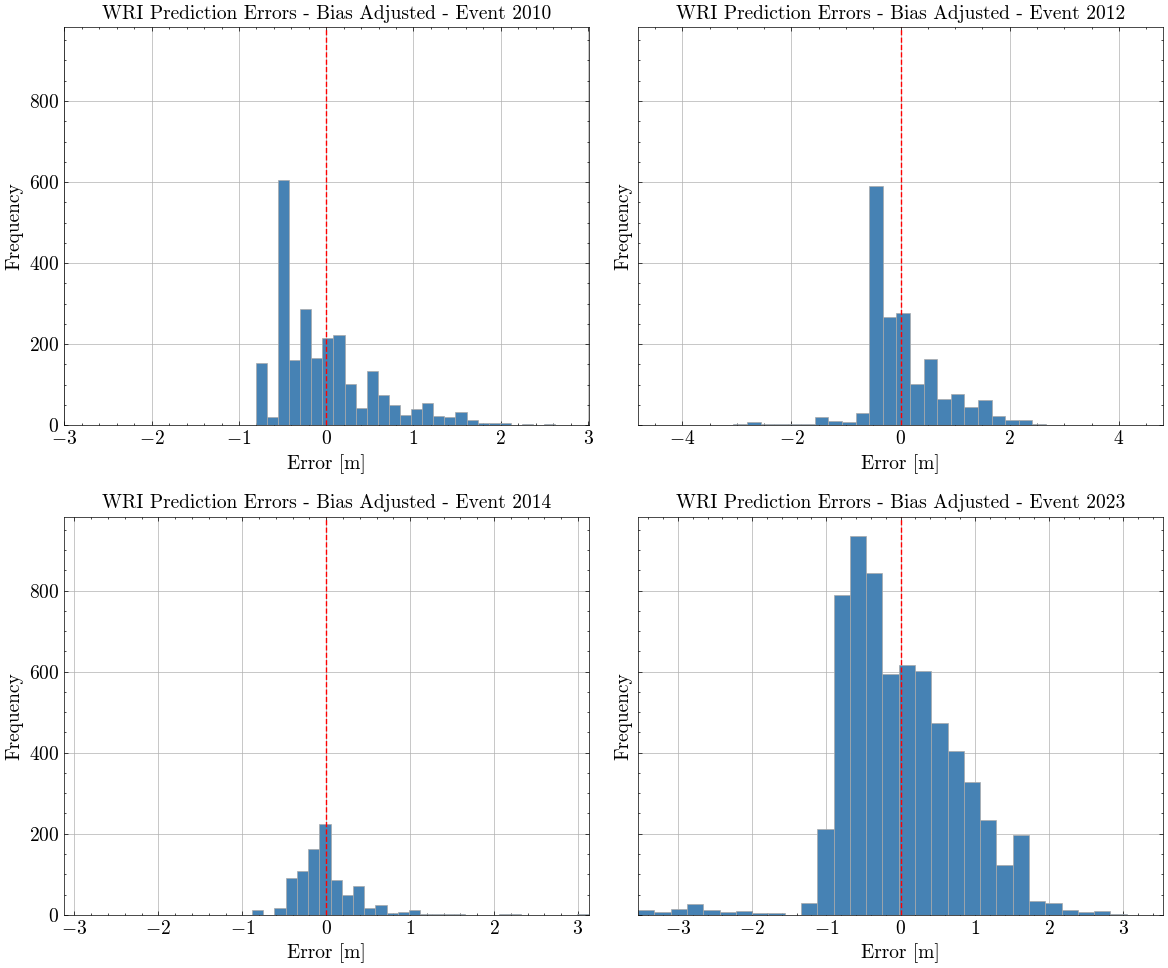

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

for idx, event_label in enumerate(events):
    row = idx // 2
    col = idx % 2
    _df = df.copy()
    _df = _df[_df["DogodekLabel"]==event_label]
    plot_errors_histogram(
        _df,
        "measured_depth",
        "predicted_wri_depth_bias_adjusted",
        title=f"WRI Prediction Errors - Bias Adjusted - Event {event_label}",
        ax=axes[row, col]
    )

plt.tight_layout()
plt.show()

In [26]:
_df = df.copy()
_df[_df["DogodekLabel"]==2010]

,VlogaId,DogodekId,DogodekLabel,gps_lat,gps_lng,measured_depth,predicted_wri_depth,predicted_si_depth,distance_to_water,si_error,wri_error,predicted_si_depth_bias_adjusted,predicted_wri_depth_bias_adjusted
0,147651,14,2010,45.555094,13.786126,0.3,0.000000,1.5,51.774728,-1.2,0.300000,1.170472,0.492904
1,147686,14,2010,45.554893,13.785861,0.5,0.000000,0.5,77.397335,0.0,0.500000,0.170472,0.492904
2,147692,14,2010,45.554893,13.785861,0.5,0.000000,0.5,77.397335,0.0,0.500000,0.170472,0.492904
3,147704,14,2010,45.555094,13.786126,0.4,0.000000,1.5,51.774728,-1.1,0.400000,1.170472,0.492904
4,147723,14,2010,45.562016,13.756194,1.3,0.482443,2.5,455.622715,-1.2,0.817557,2.170472,0.975347
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2482,152841,14,2010,46.053673,14.116583,0.6,0.000000,0.5,146.594584,0.1,0.600000,0.170472,0.492904
2483,152882,14,2010,46.044490,14.107710,1.0,0.000000,0.0,63.925865,1.0,1.000000,0.000000,0.492904
2484,153043,14,2010,46.039510,14.131731,0.0,0.000000,0.5,16.349350,-0.5,0.000000,0.170472,0.492904
2485,153113,14,2010,46.009324,14.128367,0.0,0.000000,0.5,11.764889,-0.5,0.000000,0.170472,0.492904


# Regression total results

In [27]:
print(f"Total")
_df = df.copy()
# _df = _df[_df["distance_to_water"]<100]
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth_bias_adjusted"]))
print(quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth_bias_adjusted"]))
print("-"*100)

for event_label in events:
    print(f"Event: {event_label}")
    _df = df.copy()
    _df = _df[_df["DogodekLabel"]==event_label]
    # _df = _df[_df["distance_to_water"]<100]
    print("SI IKG")
    print("    ", quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_si_depth_bias_adjusted"]))
    print("WRI Aqueduct")
    print("    ", quality_metrics.get_metrics(_df["measured_depth"], _df["predicted_wri_depth_bias_adjusted"]))
    print("-"*100)

Total
{'within_20': 0.2537, 'median_error': 0.0, 'mean_error': -0.0163, 'median_absolute_error': 0.4997609622411694, 'RMSE': 0.8504, 'st_dev_residuals': 6.8642, 'total_samples': 11740}
{'within_20': 0.2557, 'median_error': -0.1046, 'mean_error': 0.0, 'median_absolute_error': 0.49290419445819406, 'RMSE': 0.7214, 'st_dev_residuals': 5.1097, 'total_samples': 11740}
----------------------------------------------------------------------------------------------------
Event: 2010
SI IKG
     {'within_20': 0.348, 'median_error': -0.0205, 'mean_error': -0.077, 'median_absolute_error': 0.5, 'RMSE': 0.8313, 'st_dev_residuals': 2.9551, 'total_samples': 2477}
WRI Aqueduct
     {'within_20': 0.4102, 'median_error': -0.1429, 'mean_error': 0.0, 'median_absolute_error': 0.44290419445819407, 'RMSE': 0.5931, 'st_dev_residuals': 1.6976, 'total_samples': 2477}
----------------------------------------------------------------------------------------------------
Event: 2012
SI IKG
     {'within_20': 0.3422, '

In [28]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_quality_metrics(df, events, bias_adjusted: bool = False, figtitle: str = None):
    """
    Create three plots showing different quality metrics for SI and WRI depth predictions.
    
    Args:
        df (pd.DataFrame): DataFrame containing the data
        events (list): List of event IDs to analyze
    """
    # Create figure with 3 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    if figtitle:
        fig.suptitle(figtitle)

    predicted_col_si = "predicted_si_depth_bias_adjusted" if bias_adjusted else "predicted_si_depth"
    predicted_col_wri = "predicted_wri_depth_bias_adjusted" if bias_adjusted else "predicted_wri_depth"
    
    # Prepare data for plotting
    metrics = {
        "Total": {
            "si": quality_metrics.get_metrics(df["measured_depth"], df[predicted_col_si]),
            "wri": quality_metrics.get_metrics(df["measured_depth"], df[predicted_col_wri])
        }
    }
    print(f"Total")
    print(metrics["Total"])
    
    for event_label in events:
        _df = df[df["DogodekLabel"] == event_label]
        metrics[event_label] = {
            "si": quality_metrics.get_metrics(_df["measured_depth"], _df[predicted_col_si]),
            "wri": quality_metrics.get_metrics(_df["measured_depth"], _df[predicted_col_wri])
        }
        print(f"Event: {event_label}")
        print(metrics[event_label])
    
    # Extract metrics for plotting
    event_labels = list(metrics.keys())
    si_error_within_20 = [m["si"]["within_20"] for m in metrics.values()]
    wri_error_within_20 = [m["wri"]["within_20"] for m in metrics.values()]
    si_mean_error = [m["si"]["mean_error"] for m in metrics.values()]
    wri_mean_error = [m["wri"]["mean_error"] for m in metrics.values()]
    si_std_error = [m["si"]["st_dev_residuals"] for m in metrics.values()]
    wri_std_error = [m["wri"]["st_dev_residuals"] for m in metrics.values()]
    
    # Plot 1: Error within 20
    x = np.arange(len(event_labels))
    width = 0.35
    ax1.bar(x - width/2, si_error_within_20, width, label="SI IKG", color="steelblue")
    ax1.bar(x + width/2, wri_error_within_20, width, label="WRI Aqueduct", color="darkorange")
    ax1.set_ylabel("Error within 20 (%)")
    ax1.set_xlabel("Event")
    ax1.set_xticks(x)
    ax1.set_xticklabels(event_labels, rotation=45)
    # ax1.legend()
    ax1.grid()

    # Plot 2: Standard Deviation
    ax2.bar(x - width/2, si_std_error, width, label="SI", color="steelblue")
    ax2.bar(x + width/2, wri_std_error, width, label="WRI", color="darkorange")
    ax2.set_ylabel("Standard deviation")
    ax2.set_xlabel("Event")
    ax2.set_xticks(x)
    ax2.set_xticklabels(event_labels, rotation=45)
    # ax2.legend()
    ax2.grid()

    # Plot 3: mean_error
    ax3.bar(x - width/2, si_mean_error, width, label="SI", color="steelblue")
    ax3.bar(x + width/2, wri_mean_error, width, label="WRI", color="darkorange")
    ax3.set_ylabel("Mean error")
    ax3.set_xlabel("Event")
    ax3.set_xticks(x)
    ax3.set_xticklabels(event_labels, rotation=45)
    # ax3.legend()
    ax3.grid()

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=3, facecolor="white", edgecolor="black", framealpha=1)



    print(metrics)
    # Display your metrics in a clean table
    print("FLOOD DEPTH PREDICTION METRICS")
    print("="*50)
    metrics_df = display_metrics_table(metrics)
    print(metrics_df.to_string(index=False))

    # Or use the formatted summary
    print_metrics_summary(metrics)

    plt.tight_layout()
    return fig

Total
{'si': {'within_20': 0.1882, 'median_error': 0.25, 'mean_error': 0.2314, 'median_absolute_error': 0.5, 'RMSE': 0.954, 'st_dev_residuals': 5.4097, 'total_samples': 11740}, 'wri': {'within_20': 0.1175, 'median_error': 0.5118, 'mean_error': 0.7238, 'median_absolute_error': 0.6, 'RMSE': 1.0429, 'st_dev_residuals': 1.4842, 'total_samples': 11740}}
Event: 2010
{'si': {'within_20': 0.3383, 'median_error': -0.35, 'mean_error': -0.3295, 'median_absolute_error': 0.5, 'RMSE': 0.9516, 'st_dev_residuals': 3.7727, 'total_samples': 2477}, 'wri': {'within_20': 0.2794, 'median_error': 0.35, 'mean_error': 0.4929, 'median_absolute_error': 0.35, 'RMSE': 0.7712, 'st_dev_residuals': 0.528, 'total_samples': 2477}}
Event: 2012
{'si': {'within_20': 0.3267, 'median_error': 0.0, 'mean_error': 0.0977, 'median_absolute_error': 0.5, 'RMSE': 0.9973, 'st_dev_residuals': 4.5658, 'total_samples': 1797}, 'wri': {'within_20': 0.2632, 'median_error': 0.4, 'mean_error': 0.5567, 'median_absolute_error': 0.5, 'RMSE': 0

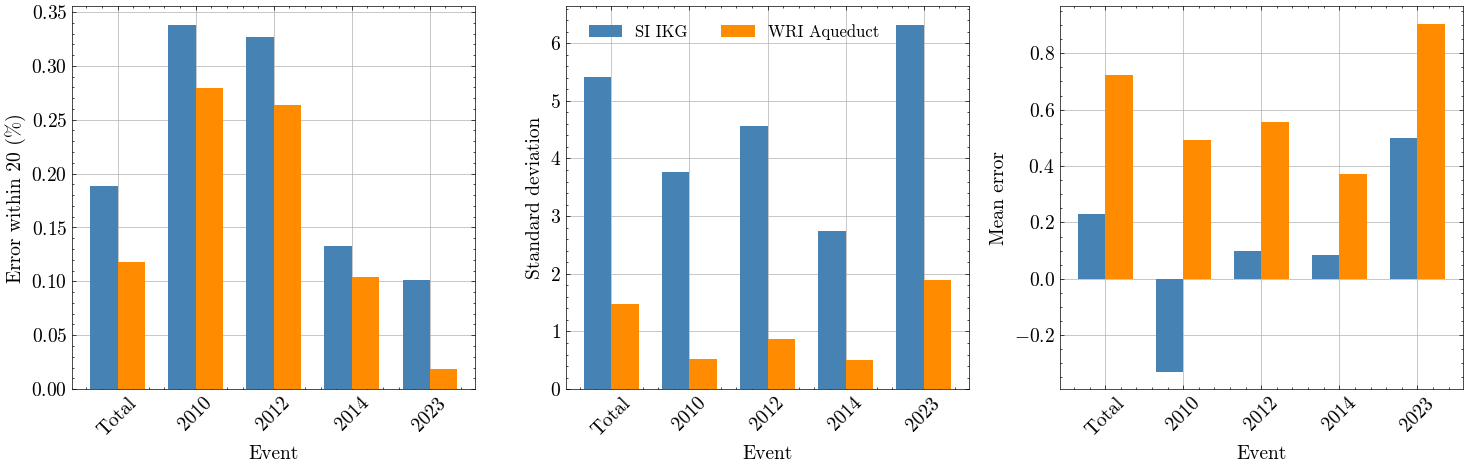

In [29]:

_df = df.copy()
# _df = _df[_df["distance_to_water"]<100]

# fig = plot_quality_metrics(_df, events, figtitle="Quality Metrics for SI and WRI Depth Predictions - Base Model, All Events")
fig = plot_quality_metrics(_df, events)#, figtitle="Quality Metrics for SI and WRI Depth Predictions - Base Model, All Events")
plt.savefig(IMAGES_PATH + "/05/regression_metrics_raw.pdf", dpi=300, bbox_inches="tight")
# Add legend to the figure

# Proximity to water analysis

Total
{'si': {'within_20': 0.1986, 'median_error': 0.2, 'mean_error': 0.1506, 'median_absolute_error': 0.5, 'RMSE': 0.935, 'st_dev_residuals': 5.6259, 'total_samples': 6691}, 'wri': {'within_20': 0.1109, 'median_error': 0.5674, 'mean_error': 0.7226, 'median_absolute_error': 0.6, 'RMSE': 1.0336, 'st_dev_residuals': 1.6237, 'total_samples': 6691}}
Event: 2010
{'si': {'within_20': 0.3309, 'median_error': -0.5, 'mean_error': -0.3941, 'median_absolute_error': 0.6, 'RMSE': 0.9849, 'st_dev_residuals': 3.8043, 'total_samples': 1369}, 'wri': {'within_20': 0.2637, 'median_error': 0.4, 'mean_error': 0.5019, 'median_absolute_error': 0.4, 'RMSE': 0.7566, 'st_dev_residuals': 0.5403, 'total_samples': 1369}}
Event: 2012
{'si': {'within_20': 0.3917, 'median_error': 0.0, 'mean_error': -0.1274, 'median_absolute_error': 0.5, 'RMSE': 0.9624, 'st_dev_residuals': 5.702, 'total_samples': 960}, 'wri': {'within_20': 0.3073, 'median_error': 0.3, 'mean_error': 0.4707, 'median_absolute_error': 0.4, 'RMSE': 0.8871,

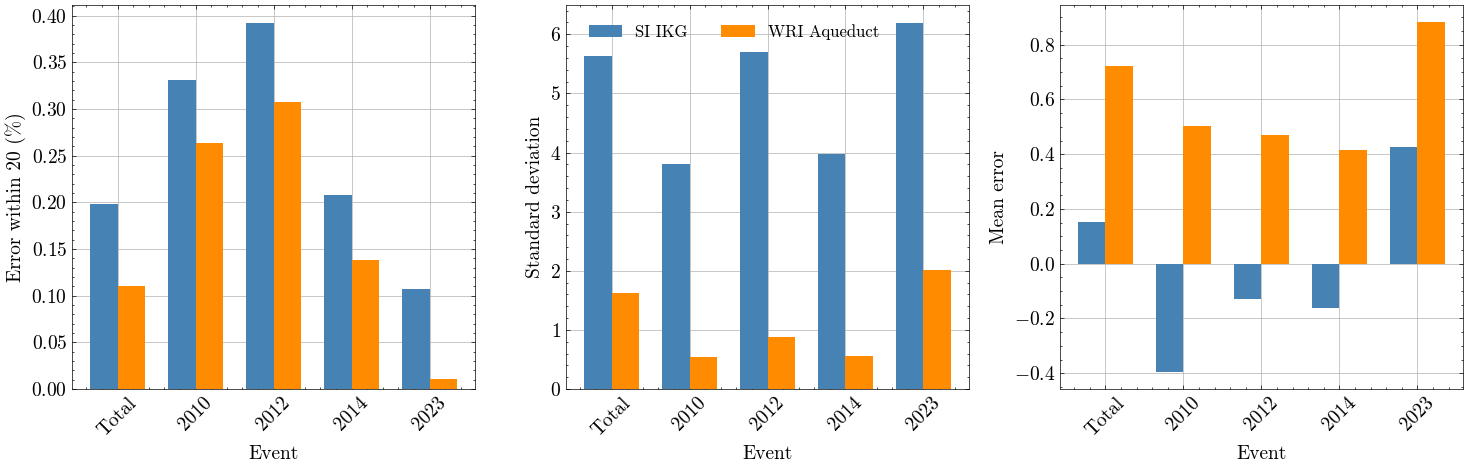

In [30]:
_df = df.copy()
_df = _df[_df["distance_to_water"]<100]

fig = plot_quality_metrics(_df, events)#, figtitle="Quality Metrics for SI and WRI Depth Predictions - Base Model, Distance to Water < 100m")
plt.savefig(IMAGES_PATH + "/05/regression_metrics_100m.pdf", dpi=300, bbox_inches="tight")

In [31]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_quality_metrics(df, events, bias_adjusted: bool = False, figtitle: str = None):
    """
    Create a plot showing different quality metrics for SI and WRI depth predictions.
    
    Args:
        df (pd.DataFrame): DataFrame containing the data
        events (list): List of event IDs to analyze
    """
    # Create figure
    fig, ax1 = plt.subplots(figsize=(10, 5))
    if figtitle:
        fig.suptitle(figtitle)

    predicted_col_si = "predicted_si_depth_bias_adjusted" if bias_adjusted else "predicted_si_depth"
    predicted_col_wri = "predicted_wri_depth_bias_adjusted" if bias_adjusted else "predicted_wri_depth"
    
    # Prepare data for plotting
    metrics = {
        "Total": {
            "si": quality_metrics.get_metrics(df["measured_depth"], df[predicted_col_si]),
            "wri": quality_metrics.get_metrics(df["measured_depth"], df[predicted_col_wri])
        }
    }
    
    for event_label in events:
        _df = df[df["DogodekLabel"] == event_label]
        metrics[event_label] = {
            "si": quality_metrics.get_metrics(_df["measured_depth"], _df[predicted_col_si]),
            "wri": quality_metrics.get_metrics(_df["measured_depth"], _df[predicted_col_wri])
        }
        print(metrics[event_label])
    
    # Extract metrics for plotting
    event_labels = list(metrics.keys())
    si_error_within_20 = [m["si"]["within_20"] for m in metrics.values()]
    wri_error_within_20 = [m["wri"]["within_20"] for m in metrics.values()]
    si_median_error = [m["si"]["median_error"] for m in metrics.values()]
    wri_median_error = [m["wri"]["median_error"] for m in metrics.values()]
    
    # Plot: Error within 20 and Median Error
    x = np.arange(len(event_labels))
    width = 0.35
    ax1.bar(x - width/2, si_error_within_20, width, label="SI Error within 20", color='b')
    ax1.bar(x + width/2, wri_error_within_20, width, label="WRI Error within 20", color='g')
    ax1.set_ylabel("Error within 20 (%)")
    ax1.set_xlabel("Event")
    ax1.set_xticks(x)
    ax1.set_xticklabels(event_labels, rotation=45)
    ax1.legend(loc='upper left')
    ax1.grid()

    # Create a second y-axis for median error
    ax2 = ax1.twinx()
    ax2.plot(x, si_median_error, label="SI Median Error", color='r', marker='o')
    ax2.plot(x, wri_median_error, label="WRI Median Error", color='y', marker='o')
    ax2.set_ylabel("Median Error")
    ax2.legend(loc='upper right')

    plt.tight_layout()
    return fig

In [32]:
# Create 4 buckets of distance to water
df["distance_to_water_bucket"] = pd.cut(df["distance_to_water"], bins=[0, 100, 200, 300], labels=[100, 200, 300])
df["distance_to_water_bucket"].value_counts()
# Nan values
# df["distance_to_water_bucket"].isna().sum()


distance_to_water_bucket
100    6691
200    2915
300    1005
Name: count, dtype: int64

In [33]:
df[df["distance_to_water"]>300].shape


(1129, 14)

Bucket, distance to water:  100
{'si': {'within_20': 0.3309, 'median_error': -0.5, 'mean_error': -0.3941, 'median_absolute_error': 0.6, 'RMSE': 0.9849, 'st_dev_residuals': 3.8043, 'total_samples': 1369}, 'wri': {'within_20': 0.2637, 'median_error': 0.4, 'mean_error': 0.5019, 'median_absolute_error': 0.4, 'RMSE': 0.7566, 'st_dev_residuals': 0.5403, 'total_samples': 1369}}
{'si': {'within_20': 0.3917, 'median_error': 0.0, 'mean_error': -0.1274, 'median_absolute_error': 0.5, 'RMSE': 0.9624, 'st_dev_residuals': 5.702, 'total_samples': 960}, 'wri': {'within_20': 0.3073, 'median_error': 0.3, 'mean_error': 0.4707, 'median_absolute_error': 0.4, 'RMSE': 0.8871, 'st_dev_residuals': 0.8731, 'total_samples': 960}}
{'si': {'within_20': 0.2075, 'median_error': 0.0, 'mean_error': -0.1614, 'median_absolute_error': 0.4, 'RMSE': 0.786, 'st_dev_residuals': 3.9778, 'total_samples': 318}, 'wri': {'within_20': 0.1384, 'median_error': 0.3, 'mean_error': 0.4168, 'median_absolute_error': 0.3, 'RMSE': 0.634, 's

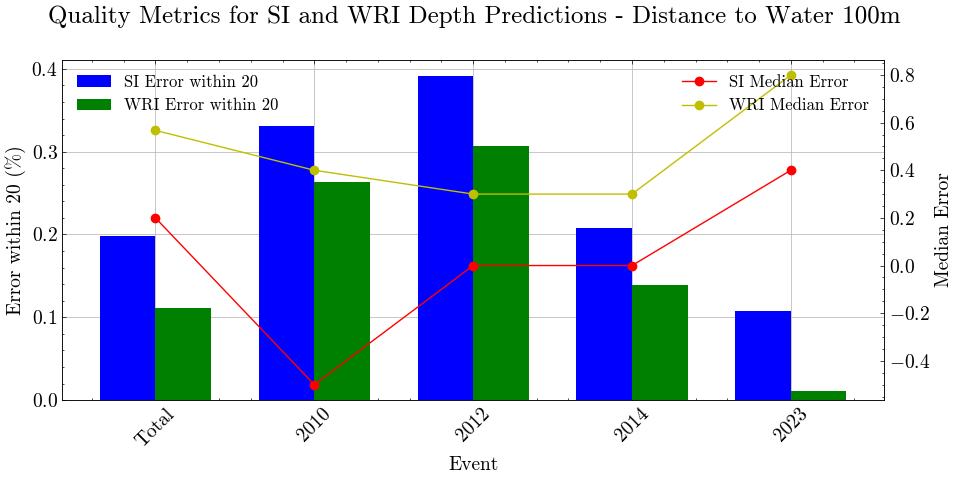

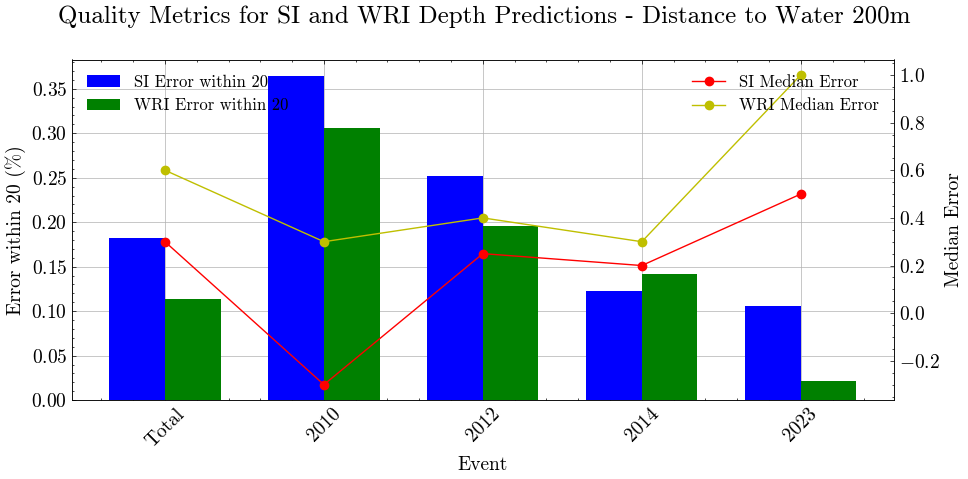

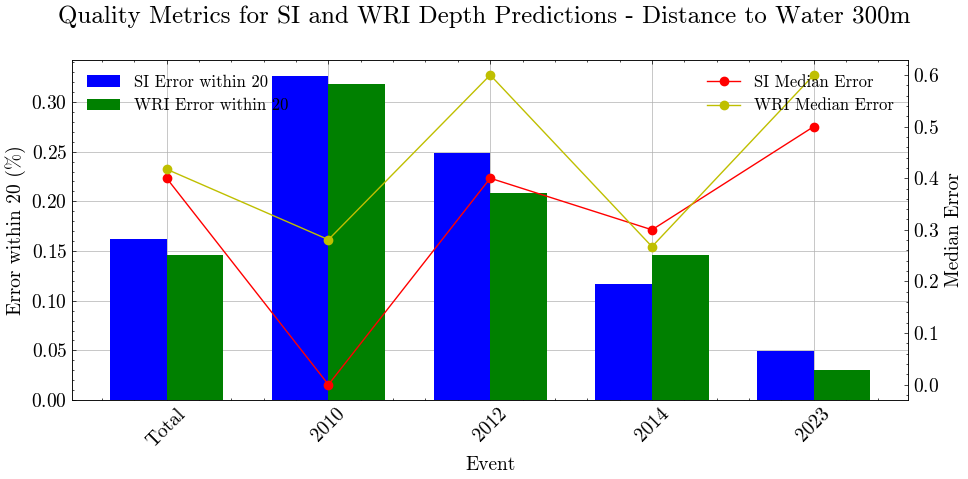

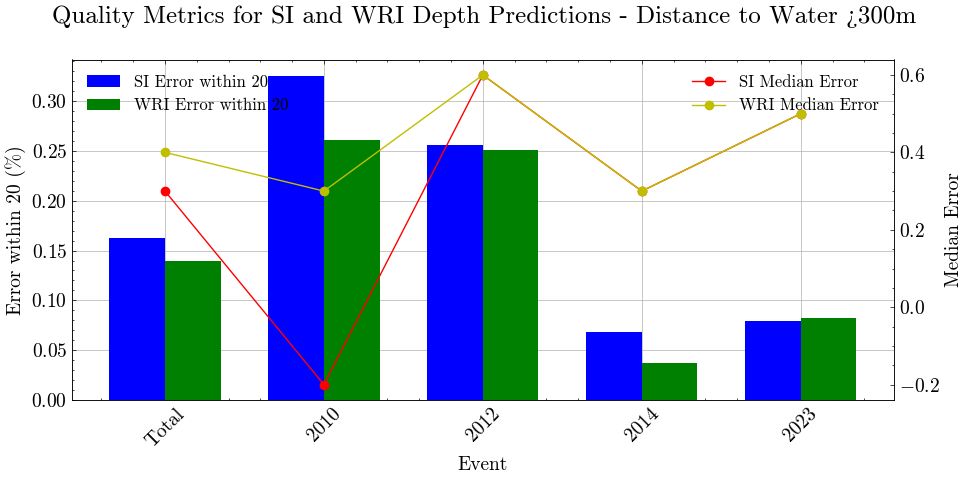

In [34]:
_df = df.copy()
for bucket in [100, 200, 300, ">300"]:
    if bucket == ">300":
        _df = df[df["distance_to_water"]>300]
    else:
        _df = df[df["distance_to_water_bucket"] == bucket]
    print("Bucket, distance to water: ", bucket)
    fig = plot_quality_metrics(_df, events, figtitle=f"Quality Metrics for SI and WRI Depth Predictions - Distance to Water {bucket}m")

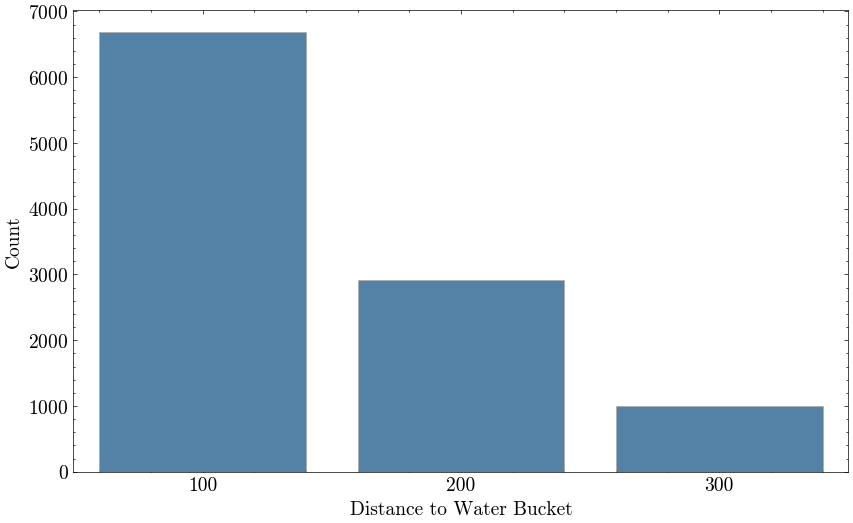

In [35]:
# Plot count by distance_to_water_bucket
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="distance_to_water_bucket", color="steelblue", edgecolor="darkgrey", linewidth=0.5)
plt.xlabel("Distance to Water Bucket")
plt.ylabel("Count")
plt.show()


----------

# Categorize measured_depth into 4 categories


In [36]:
df["depth_category"] = pd.cut(df["measured_depth"], bins=[0, 0.5, 1.5, 2.5], labels=[0.5, 1.5, 2.5])
# df.shape
# df.head()
# df.groupby("depth_category").mean()
# df.groupby("depth_category").mean()

In [37]:
df["depth_category"].value_counts().sort_index()


depth_category
0.5    4277
1.5    4334
2.5    1757
Name: count, dtype: int64

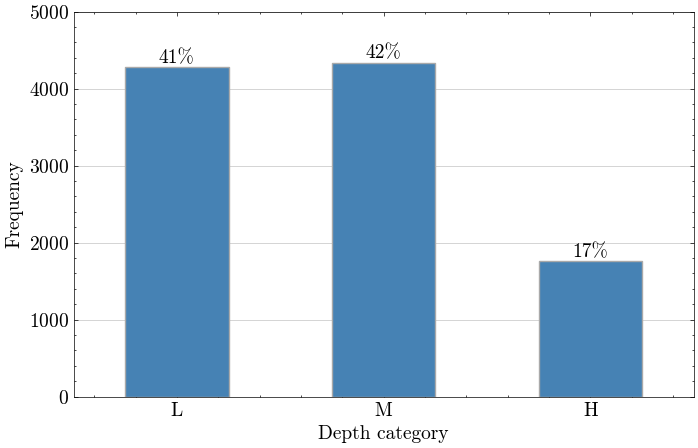

In [38]:
value_counts = df["depth_category"].value_counts().sort_index()
value_counts.plot(kind="bar", edgecolor="darkgrey", color="steelblue", figsize=(8, 5))


# Calculate relative percentages
total_count = value_counts.sum()
percentages = (value_counts / total_count) * 100

# Add text with percentages below the title
# percent_text = ", ".join([f"{cat}: {count} ({percent:.0f}%)" for cat, count, percent in zip(value_counts.index, value_counts, percentages)])
# plt.title(f"Histogram of Depth Category Counts\n{percent_text}")

plt.xlabel("Depth category")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)

# Change labels to L, M, H
plt.xticks(range(len(value_counts)), ["L", "M", "H"], rotation=0)
plt.ylim(0, 5000)

# Add % to the chart its on top of the bars
for i, (cat, v) in enumerate(value_counts.items()):
    plt.text(i, v + 10, f"{percentages[cat]:.0f}%", ha="center", va="bottom")

plt.savefig(IMAGES_PATH + "/05/validation_depth_classes.pdf", dpi=300, bbox_inches="tight")
plt.show()

<Axes: xlabel='depth_category', ylabel='predicted_si_depth'>

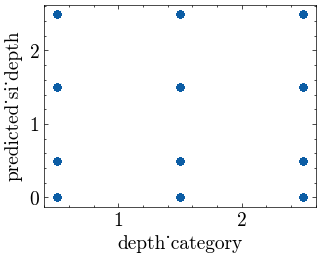

In [39]:
df.plot(x="depth_category", y="predicted_si_depth", kind="scatter")

In [40]:
def plot_confusion_matrix(df, true_column, predicted_column, title: str = "Confusion matrix"):
    # First, let's bin the measured_depth into categories and do the same for predictions
    # Create categorical bins for the depths
    def categorize_depth(depth):
        if depth <= 0.5:
            return "0.5"
        elif depth <= 1.5:
            return "1.5"
        return "2.5"
    
    _df = df.copy()
    
    _df["depth_category_true"] = _df[true_column].apply(categorize_depth)
    _df["depth_category_pred"] = _df[predicted_column].apply(categorize_depth)

    # Calculate confusion matrix
    cm = confusion_matrix(_df["depth_category_true"], _df["depth_category_pred"])
    categories = ["S", "M", "H"]

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=categories, 
                yticklabels=categories)
    # plt.title(title)
    plt.xlabel("Predicted category")
    plt.ylabel("True category")
    # plt.show()

    # ---
    # Calculate metrics
    # ---
    accuracy = accuracy_score(_df["depth_category_true"], _df["depth_category_pred"])
    precision, recall, f1, support = precision_recall_fscore_support(
        _df["depth_category_true"], 
        _df["depth_category_pred"],
        labels=["0.5", "1.5", "2.5"],
        average=None
    )

    # Calculate additional multiclass metrics
    macro_precision = precision_recall_fscore_support(
        _df["depth_category_true"], 
        _df["depth_category_pred"],
        labels=["0.5", "1.5", "2.5"],
        average="macro"
    )[0]
    
    macro_recall = precision_recall_fscore_support(
        _df["depth_category_true"], 
        _df["depth_category_pred"],
        labels=["0.5", "1.5", "2.5"],
        average="macro"
    )[1]
    
    macro_f1 = precision_recall_fscore_support(
        _df["depth_category_true"], 
        _df["depth_category_pred"],
        labels=["0.5", "1.5", "2.5"],
        average="macro"
    )[2]

    metrics_df = pd.DataFrame({
        "Category": ["0.5", "1.5", "2.5"],
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Support": support
    })

    # Print overall accuracy
    print(f"Overall Classification Accuracy: {accuracy:.3f}\n")

    # Print per-category metrics
    print("Per-category metrics:")
    print(metrics_df.to_string(index=False))

    # Print macro metrics
    print("\nMacro-averaged metrics:")
    print(f"Macro Precision: {macro_precision:.3f}")
    print(f"Macro Recall: {macro_recall:.3f}")
    print(f"Macro F1-Score: {macro_f1:.3f}")

    """
    Metrics explanation:
    - Accuracy: Proportion of correct predictions among total predictions
    - Precision: Proportion of correct positive predictions among all positive predictions for each category
    - Recall: Proportion of correct positive predictions among all actual positives for each category
    - F1-Score: Harmonic mean of precision and recall for each category
    - Support: Number of samples in each category
    - Macro Precision/Recall/F1-Score: Average of the precision/recall/f1-score for all categories
    """

WRI
Overall Classification Accuracy: 0.461

Per-category metrics:
Category  Precision   Recall  F1-Score  Support
     0.5   0.493299 0.779197  0.604131     5480
     1.5   0.388762 0.236271  0.293915     4334
     2.5   0.275556 0.064382  0.104377     1926

Macro-averaged metrics:
Macro Precision: 0.386
Macro Recall: 0.360
Macro F1-Score: 0.334


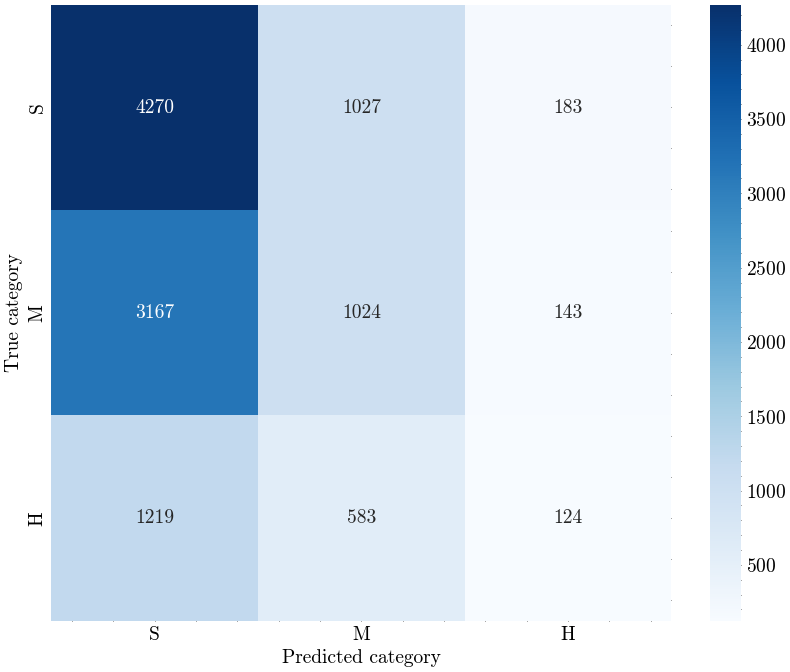

In [41]:
print("WRI")
plot_confusion_matrix(df, "measured_depth", "predicted_si_depth", title="Confusion Matrix [SI IKG]")

SI IKG - Bias Adjusted
Overall Classification Accuracy: 0.432

Per-category metrics:
Category  Precision   Recall  F1-Score  Support
     0.5   0.520014 0.559489  0.539030     5480
     1.5   0.373126 0.315874  0.342122     4334
     2.5   0.292414 0.330218  0.310168     1926

Macro-averaged metrics:
Macro Precision: 0.395
Macro Recall: 0.402
Macro F1-Score: 0.397


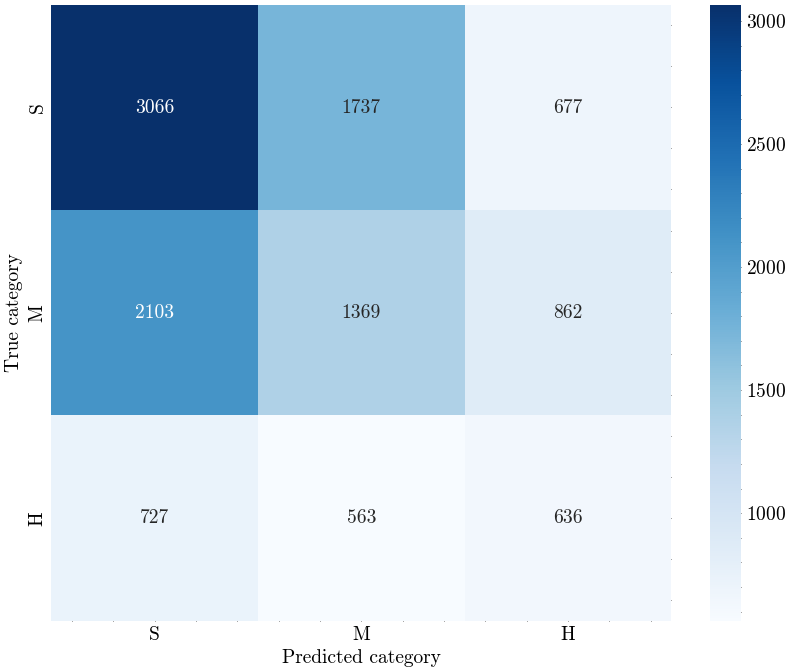

In [45]:
print("SI IKG - Bias Adjusted")
plot_confusion_matrix(df, "measured_depth", "predicted_si_depth_bias_adjusted", title="Confusion Matrix [SI IKG - Bias Adjusted]")
plt.savefig(IMAGES_PATH + "/05/confusion_matrix_si_ikg_bias_adjusted.pdf", dpi=300, bbox_inches="tight")

Overall Classification Accuracy: 0.464

Per-category metrics:
Category  Precision   Recall  F1-Score  Support
     0.5   0.468249 0.986314  0.635023     5480
     1.5   0.277778 0.003461  0.006837     4334
     2.5   0.209790 0.015576  0.029000     1926

Macro-averaged metrics:
Macro Precision: 0.319
Macro Recall: 0.335
Macro F1-Score: 0.224


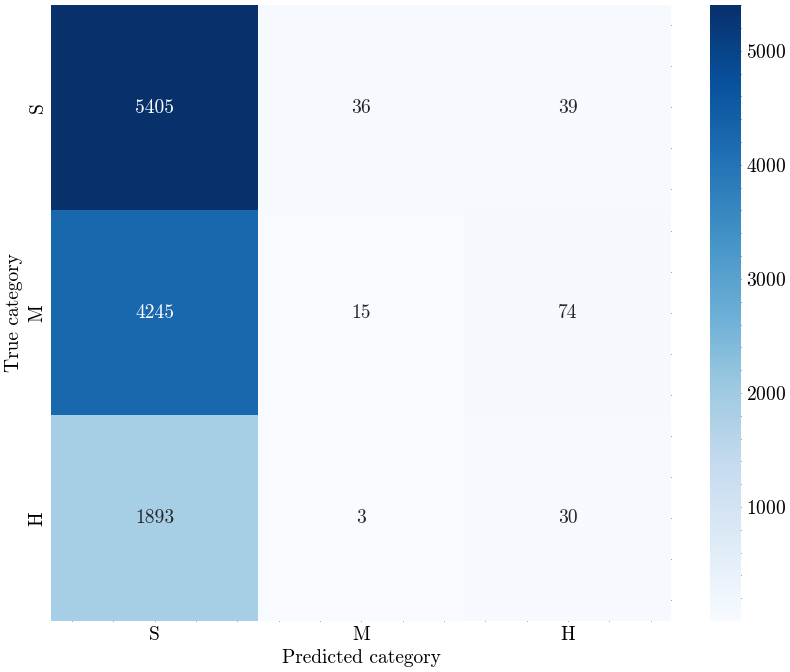

In [43]:
plot_confusion_matrix(df, "measured_depth", "predicted_wri_depth", title="Confusion Matrix [WRI]")

WRI - Bias Adjusted
Overall Classification Accuracy: 0.459

Per-category metrics:
Category  Precision   Recall  F1-Score  Support
     0.5   0.683244 0.325912  0.441315     5480
     1.5   0.397863 0.824642  0.536758     4334
     2.5   0.209790 0.015576  0.029000     1926

Macro-averaged metrics:
Macro Precision: 0.430
Macro Recall: 0.389
Macro F1-Score: 0.336


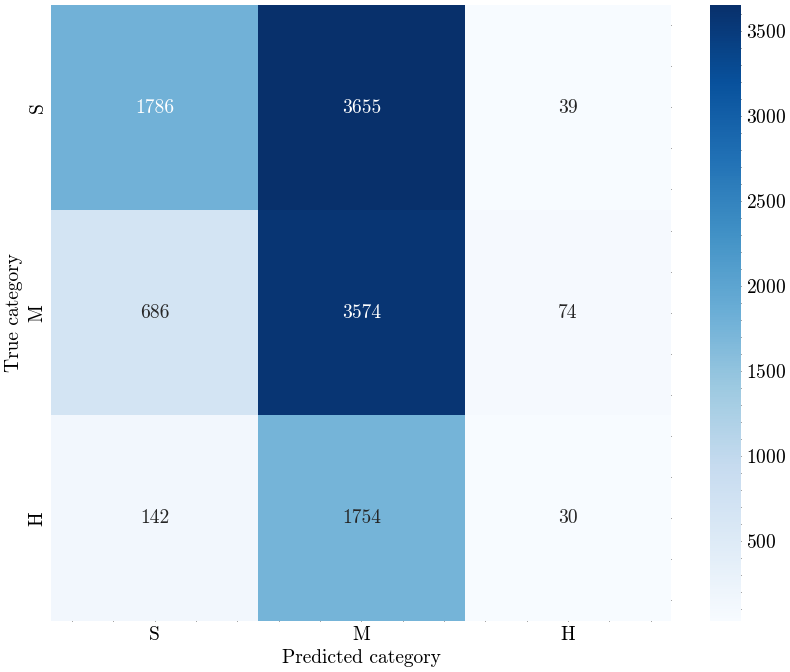

In [44]:
print("WRI - Bias Adjusted")
plot_confusion_matrix(df, "measured_depth", "predicted_wri_depth_bias_adjusted", title="Confusion Matrix [WRI - Bias Adjusted]")
plt.savefig(IMAGES_PATH + "/05/confusion_matrix_wri_bias_adjusted.pdf", dpi=300, bbox_inches="tight")

In [163]:
# Statistics

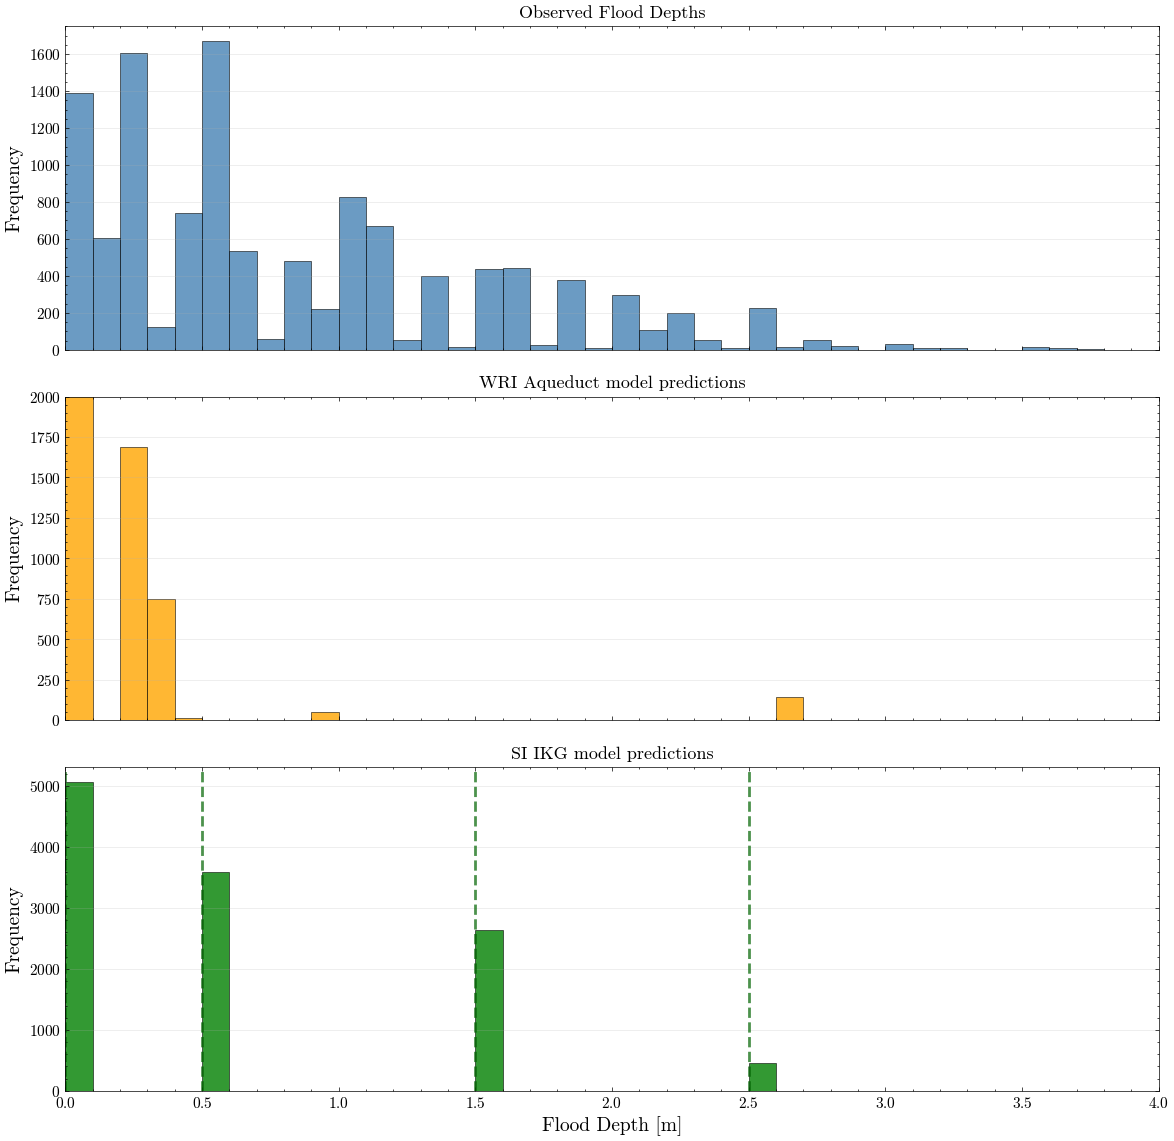

Model Performance Comparison:
--------------------------------------------------
Observed mean: 0.817m
Observed range: 0.00 - 3.95m
Observed length: 11740
WRI Model (Continuous):
  LEN: 11740
  AVG: 0.093m
  MAE: 0.781m
  RMSE: 1.043m
  Range: 0.00 - 4.75m

IKG Model (Discrete):
  LEN: 11740
  AVG: 0.585m
  MAE: 0.732m
  RMSE: 0.954m
  Discrete values: [0.0, 0.5, 1.5, 2.5]
  Value distribution: {0.0: 5063, 0.5: 3593, 1.5: 2634, 2.5: 450}


In [ ]:
# Alternative visualization emphasizing discrete vs continuous nature
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Consistent bins for all three plots
bins = np.arange(0, 4.1, 0.1)

# Plot 1: Observed depths
ax1.hist(df["measured_depth"], bins=bins, alpha=0.8, color="steelblue", 
         edgecolor="darkgrey", linewidth=0.5)
ax1.set_ylabel("Frequency", fontsize=14)
ax1.set_title("Observed Flood Depths", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
# ax1.text(0.02, 0.95, f"n={len(df['measured_depth'])}", transform=ax1.transAxes, 
#          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: WRI predictions (continuous)
ax2.hist(df["predicted_wri_depth"], bins=bins, alpha=0.8, color="orange", 
         edgecolor="darkgrey", linewidth=0.5)
ax2.set_ylabel("Frequency", fontsize=14)
ax2.set_title("WRI Aqueduct model predictions", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# ax2.text(0.02, 0.95, f"Continuous distribution", transform=ax2.transAxes, 
#          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 3: IKG predictions (discrete) - use step plot to emphasize discrete nature
counts, bin_edges = np.histogram(df["predicted_si_depth"], bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

ax3.hist(df["predicted_si_depth"], bins=bins, alpha=0.8, color="green", 
         edgecolor="darkgrey", linewidth=0.5)

# Overlay discrete values as vertical lines to emphasize discrete nature
unique_values = sorted(df["predicted_si_depth"].unique())
for val in unique_values:
    count = (df["predicted_si_depth"] == val).sum()
    ax3.axvline(x=val, color='darkgreen', linestyle='--', alpha=0.7, linewidth=2)
    # ax3.text(val, count + 50, f'{val}m', ha='center', va='bottom', 
    #          fontsize=10, fontweight='bold', color='darkgreen')

ax3.set_ylabel("Frequency", fontsize=14)
ax3.set_xlabel("Flood Depth [m]", fontsize=14)
ax3.set_title("SI IKG model predictions", fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
# ax3.text(0.02, 0.95, f"Discrete values: {unique_values}", transform=ax3.transAxes, 
#          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

# Set common x-axis properties
for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 4)
    ax.set_xticks(np.arange(0, 4.5, 0.5))

ax2.set_ylim(0, 2000)

# plt.suptitle("Comparison of Flood Depth Distributions: Observed vs. WRI vs. IKG at RP100", 
#              fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.savefig(IMAGES_PATH + "/05/depth_distribution_histograms.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Statistical comparison
print("Model Performance Comparison:")
print("-" * 50)
observed = df["measured_depth"]
wri_pred = df["predicted_wri_depth"] 
ikg_pred = df["predicted_si_depth"]

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate metrics
wri_mae = mean_absolute_error(observed, wri_pred)
wri_rmse = np.sqrt(mean_squared_error(observed, wri_pred))
ikg_mae = mean_absolute_error(observed, ikg_pred)
ikg_rmse = np.sqrt(mean_squared_error(observed, ikg_pred))

print(f"Observed mean: {observed.mean():.3f}m")
print(f"Observed range: {observed.min():.2f} - {observed.max():.2f}m")
print(f"Observed length: {len(observed)}")

print(f"WRI Model (Continuous):")
print(f"  LEN: {len(wri_pred)}")
print(f"  AVG: {wri_pred.mean():.3f}m")
print(f"  MAE: {wri_mae:.3f}m")
print(f"  RMSE: {wri_rmse:.3f}m")
print(f"  Range: {wri_pred.min():.2f} - {wri_pred.max():.2f}m")

print(f"\nIKG Model (Discrete):")
print(f"  LEN: {len(ikg_pred)}")
print(f"  AVG: {ikg_pred.mean():.3f}m")
print(f"  MAE: {ikg_mae:.3f}m") 
print(f"  RMSE: {ikg_rmse:.3f}m")
print(f"  Discrete values: {unique_values}")
print(f"  Value distribution: {dict(df['predicted_si_depth'].value_counts().sort_index())}")



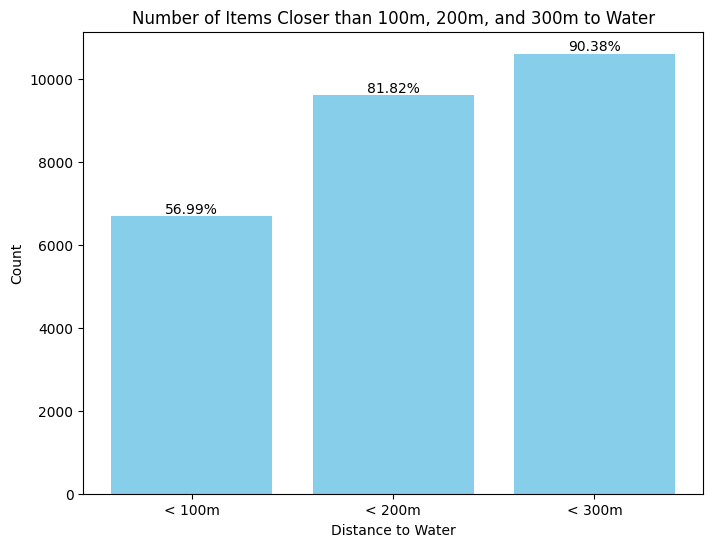

In [166]:
import matplotlib.pyplot as plt

# Define distance thresholds
distance_thresholds = [100, 200, 300]
close_items_counts = []
percentages_close_items = []

# Calculate counts and percentages for each threshold
total_items_count = df.shape[0]
for threshold in distance_thresholds:
    close_items = df[df["distance_to_water"] < threshold]
    close_items_count = close_items.shape[0]
    percentage_close_items = (close_items_count / total_items_count) * 100
    close_items_counts.append(close_items_count)
    percentages_close_items.append(percentage_close_items)

# Plot the results
plt.figure(figsize=(8, 6))
plt.bar([f"< {threshold}m" for threshold in distance_thresholds], close_items_counts, color="skyblue")
plt.title("Number of Items Closer than 100m, 200m, and 300m to Water")
plt.ylabel("Count")
plt.xlabel("Distance to Water")

# Annotate the bars with the percentages
for i, (count, percentage) in enumerate(zip(close_items_counts, percentages_close_items)):
    plt.text(i, count, f"{percentage:.2f}%", ha="center", va="bottom")

plt.show()
